# Figure 1

Panels e and f: three methylation callers wrapped as agents by the same route, and their
site-level consensus, against the whole-genome bisulfite reference on chromosome 22.

The code in each cell is `scripts/paper/consensus_panels.py`, which is the paper's
`16_make_figure4_panels.py` copied verbatim.

In [1]:
import sys; sys.path.insert(0, "../scripts"); sys.path.insert(0, "../scripts/paper")
from pathlib import Path
from nbkit import setup, paper_py, paper_r, run_r_source, harvest, show, have_r_package, DATA

OUT = setup("../figures/notebook")
print("panels will be written to", OUT)

# %%R cells below run R natively in this kernel through rpy2, so the R panels are R code
# in the notebook rather than a string that gets written to a file.
%load_ext rpy2.ipython

panels will be written to ./figures/notebook


## Figure 1e - three callers and their consensus

Correlation on top, error below. The two do not rank the callers the same way: Rockfish edges LongVerse on r and loses to it on error, which is why the panel shows both.

  panel_f_consensus  5 series over 1,381,961 sites, r and RMSE


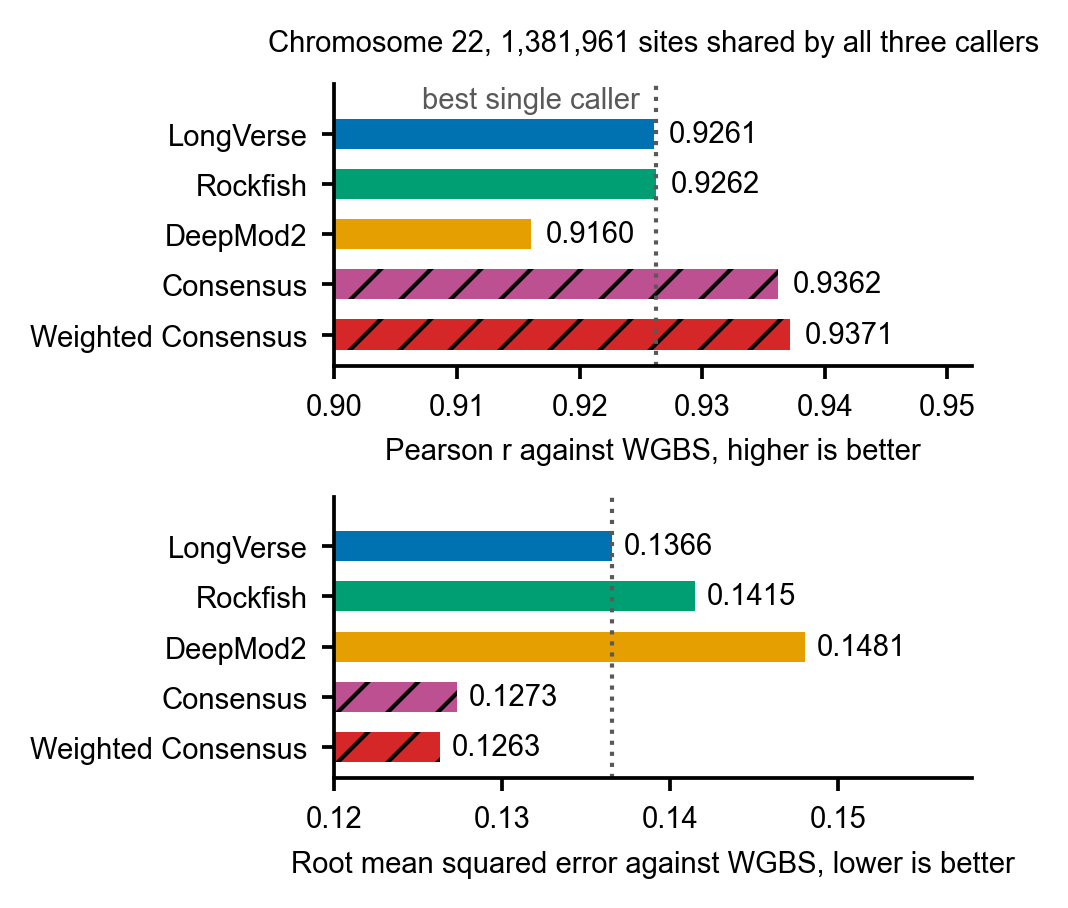

In [2]:
import os
os.environ["PANEL_FIG_W"] = "3.35"
os.environ["PANEL_FIG_H_SCALE"] = "1.15"
os.environ["PANEL_LEGEND_ABOVE"] = "1"

# From scripts/paper/consensus_panels.py, the paper's own code. Edit and re-run freely;
# the file on disk is unchanged.
import importlib.util
_s = importlib.util.spec_from_file_location("consensus_panels", "../scripts/paper/consensus_panels.py")
consensus_panels = importlib.util.module_from_spec(_s); _s.loader.exec_module(consensus_panels)
globals().update({k: v for k, v in vars(consensus_panels).items() if not k.startswith("__")})

def panel_f_consensus() -> None:
    """Three callers and their consensus against the bisulfite reference.

    All six series are scored on the same 1,381,961 chromosome 22 sites, the ones every
    caller and the truth share, so a bar can never be higher because that caller reached
    more of the chromosome. Chromosome 22 is held out from DeepMod2's training set, which
    is why the experiment is on chromosome 22 rather than on the chromosome 20 used
    elsewhere in this figure.

    The axis starts at 0.90 rather than 0, which exaggerates differences. That is the
    point of the panel, the differences are small, and the numbers are printed on the bars
    so the exaggeration cannot mislead anyone who reads them.
    """
    rows = {r["series"]: r for r in _read_csv(ENS / "consensus_three_tools.csv")}
    # The three callers and the two ways of combining all three. The pairwise means are
    # measured too and are kept in this panel's source data with a drawn_in_panel column,
    # so a reader can see that the drawn series are not the only ones that beat the singles.
    # LongVerse, Rockfish, DeepMod2, then the two rules: the same order the by-depth panel
    # draws its legend in, so e and f read down the same list (the author's call, 2026-10-04).
    order = ["longverse", "rockfish", "deepmod2", "mean_all", "coverage_mean_all"]
    vals = [float(rows[k]["pearson_r_vs_wgbs"]) for k in order]
    n_sites = int(rows["longverse"]["n_sites"])
    best_single = max(vals[:3])

    # Correlation on top, error below. A correlation alone can be read as a ranking of
    # agreement while saying nothing about how far off a call actually is, and the two do
    # not order the callers the same way here: Rockfish edges LongVerse on r and loses to
    # it on error. Showing one without the other would hide that.
    rmse = [float(rows[k]["rmse_vs_wgbs"]) for k in order]
    best_single_rmse = min(rmse[:3])

    # PANEL_SPLIT_F: the two metrics as two files, for a poster that places them apart.
    # Without it, one figure with the two axes stacked, exactly as the journal has it.
    if SPLIT_F:
        fig, ax = plt.subplots(figsize=_fs(6.4, 2.6))
        fig2, axe = plt.subplots(figsize=_fs(6.4, 2.6))
    else:
        fig, (ax, axe) = plt.subplots(2, 1, figsize=_fs(6.4, 5.05), sharey=True)
    y = list(range(len(order)))[::-1]
    colours = [ENS_C[k] for k in order]
    hatches = ["", "", "", "//", "//"]

    bars = ax.barh(y, vals, height=0.60, color=colours, hatch=hatches)
    for rect, v in zip(bars, vals):
        ax.text(v + 0.0012, rect.get_y() + rect.get_height() / 2, f"{v:.4f}",
                va="center", ha="left", fontsize=panel_style.MIN_PT)
    ax.axvline(best_single, color="#595959", lw=1.0, ls=":")
    # Above the top bar, not under the axis: at the 12 pt floor this label collided with
    # the x tick labels when it sat below the axis.
    ax.set_ylim(-0.62, len(order) - 0.02)
    ax.text(best_single - 0.0013, len(order) - 0.34, "best single caller",
            ha="right", va="center", fontsize=panel_style.MIN_PT, color="#595959")
    ax.set_yticks(y)
    ax.set_yticklabels([ENS_LABEL[k] for k in order], fontsize=panel_style.MIN_PT)
    ax.set_xlim(0.900, 0.952)
    ax.set_xlabel(L("Pearson r against WGBS, higher is better", "Pearson r vs WGBS"),
                  fontsize=panel_style.MIN_PT)
    # In poster mode the long title is wider than the 5.3 in canvas. matplotlib's tight
    # bounding box then grows to include it, the saved PNG comes out 6.6 in wide, and two
    # of them no longer fit side by side in a column. The short title is the fix at source.
    if not SPLIT_F:                      # split panels carry their own poster header
        ax.set_title(L(f"Chromosome 22, {n_sites:,} sites shared by all three callers",
                       f"chr22, {n_sites:,} shared sites"),
                     fontsize=panel_style.MIN_PT, pad=8)
    ax.tick_params(labelsize=panel_style.MIN_PT)

    ebars = axe.barh(y, rmse, height=0.60, color=colours, hatch=hatches)
    for rect, v in zip(ebars, rmse):
        axe.text(v + 0.0007, rect.get_y() + rect.get_height() / 2, f"{v:.4f}",
                 va="center", ha="left", fontsize=panel_style.MIN_PT)
    axe.axvline(best_single_rmse, color="#595959", lw=1.0, ls=":")
    if SPLIT_F:                          # no shared y axis to inherit these from
        axe.set_ylim(-0.62, len(order) - 0.02)
        axe.set_yticks(y)
        axe.set_yticklabels([ENS_LABEL[k] for k in order], fontsize=panel_style.MIN_PT)
    axe.set_xlim(0.120, 0.158)
    axe.set_xlabel(L("Root mean squared error against WGBS, lower is better",
                     "RMSE vs WGBS, lower is better"), fontsize=panel_style.MIN_PT)
    axe.tick_params(labelsize=panel_style.MIN_PT)

    for a in (ax, axe):
        for sp in ("top", "right"):
            a.spines[sp].set_visible(False)
    if SPLIT_F:
        for f_, stem in ((fig, "panel_f_pearson"), (fig2, "panel_f_rmse")):
            f_.tight_layout()
            for ext in ("pdf", "png"):
                f_.savefig(OUT_DIR / f"{stem}.{ext}")
            plt.close(f_)
    else:
        fig.tight_layout()
        for ext in ("pdf", "png"):
            fig.savefig(OUT_DIR / f"panel_f_consensus.{ext}")
        plt.close(fig)

    with open(SRC / "panel_f_consensus.csv", "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["series", "pearson_r_vs_wgbs", "rmse_vs_wgbs", "n_sites",
                    "is_consensus", "drawn_in_panel"])
        for k in ["longverse", "deepmod2", "rockfish", "mean_longverse_deepmod2",
                  "mean_longverse_rockfish", "mean_deepmod2_rockfish", "mean_all",
                  "coverage_mean_all"]:
            if k not in rows:
                continue
            w.writerow([ENS_LABEL.get(k, k), rows[k]["pearson_r_vs_wgbs"],
                        rows[k]["rmse_vs_wgbs"], rows[k]["n_sites"],
                        "no" if k in ("longverse", "deepmod2", "rockfish") else "yes",
                        "yes" if k in order else "no"])
    print(f"  panel_f_consensus  {len(order)} series over {n_sites:,} sites, "
          f"r and RMSE")

panel_f_consensus()
show("panel_f_consensus.png")

## Figure 1f - the same comparison by read depth

The lower axis is where the consensus earns its keep.

  panel_g_by_coverage  6 depth bins, gain +0.0055 to +0.0489


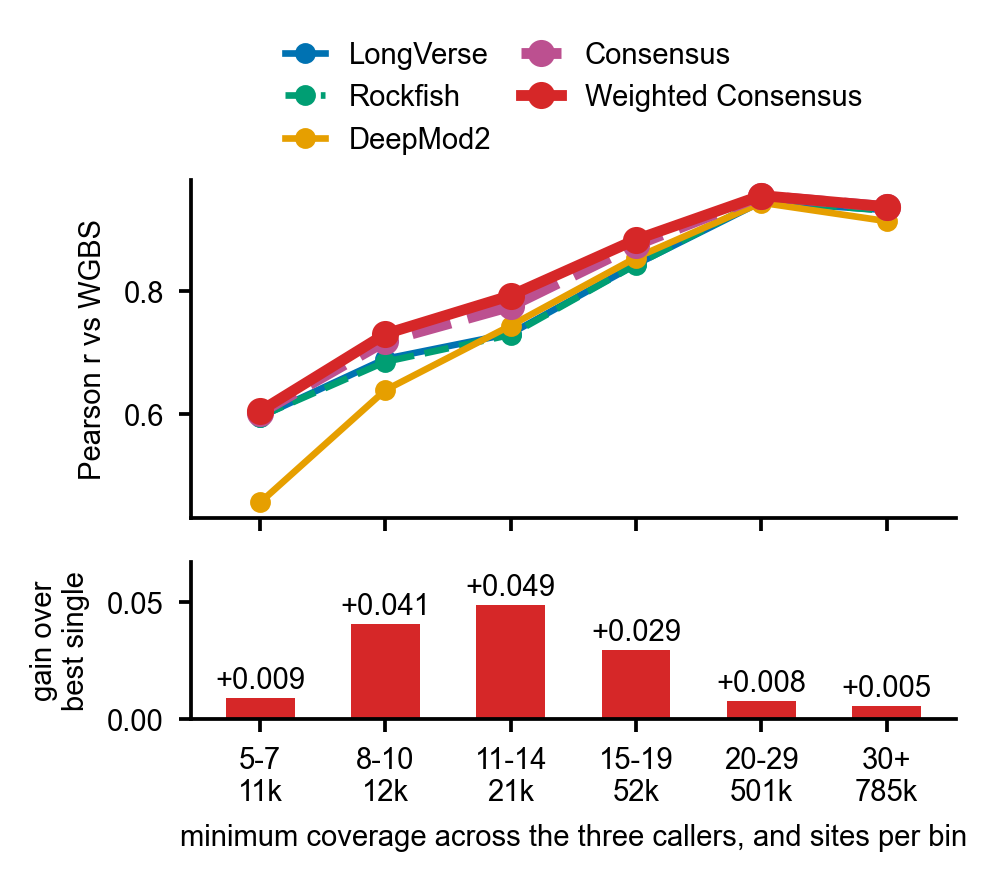

In [3]:
import os
os.environ["PANEL_FIG_W"] = "3.35"
os.environ["PANEL_FIG_H_SCALE"] = "1.15"
os.environ["PANEL_LEGEND_ABOVE"] = "1"

# From scripts/paper/consensus_panels.py, the paper's own code. Edit and re-run freely;
# the file on disk is unchanged.
import importlib.util
_s = importlib.util.spec_from_file_location("consensus_panels", "../scripts/paper/consensus_panels.py")
consensus_panels = importlib.util.module_from_spec(_s); _s.loader.exec_module(consensus_panels)
globals().update({k: v for k, v in vars(consensus_panels).items() if not k.startswith("__")})

def panel_g_by_coverage() -> None:
    """The same comparison split by read depth.

    Binned by the MINIMUM coverage across the three callers, because that is the depth
    actually available to a consensus and because one binning variable keeps every curve
    on the same rows.

    The lower axis is the finding. Averaging callers buys almost nothing where the data is
    already deep and buys a great deal where it is thin, which is what averaging noise is
    supposed to do. A panel showing only the upper axis would let a reader conclude the
    consensus is uniformly slightly better, which is not what was measured.
    """
    rows = _read_csv(ENS / "consensus_by_coverage.csv")
    bins = sorted({(int(r["bin_lo"]), r["bin"]) for r in rows})
    labels = [b[1] for b in bins]
    x = list(range(len(bins)))
    by = {}
    for r in rows:
        by.setdefault(r["series"], {})[r["bin"]] = float(r["pearson_r_vs_wgbs"])
    n_by_bin = {}
    for r in rows:
        n_by_bin[r["bin"]] = int(r["n_sites"])

    singles = ["longverse", "deepmod2", "rockfish"]
    shown = ["longverse", "rockfish", "deepmod2", "mean_all", "coverage_mean_all"]

    fig, (ax, axd) = plt.subplots(2, 1, figsize=_fs(6.4, 4.9), sharex=True,
                                  gridspec_kw={"height_ratios": [2.15, 1.0]})
    # LongVerse and Rockfish sit on top of each other at almost every depth, which is the
    # result, but a solid green line over a solid blue one just hides the blue. Rockfish is
    # dashed so both are readable where they coincide.
    for k in shown:
        thick = k in ("mean_all", "coverage_mean_all")
        ax.plot(x, [by[k][b] for b in labels], marker="o",
                ms=5.5 if thick else 4.0, lw=2.6 if thick else 1.6,
                ls="--" if k in ("rockfish", "mean_all") else "-",
                color=ENS_C[k], label=ENS_LABEL[k], zorder=3 if thick else 2)
    ax.set_ylabel(L("Pearson r vs WGBS", "Pearson r"), fontsize=panel_style.MIN_PT)
    # Poster: the legend goes ABOVE the axes, in a row. At double height there is no empty
    # corner inside the plot: lower right sat on DeepMod2's rise from r = 0.45, upper left
    # sat on the consensus curves at 11 to 14x. Outside the axes it can cover nothing. The
    # in-figure title is dropped in the same mode, the poster's panel header already names
    # the panel. The journal figure keeps its signed off layout.
    if LEGEND_ABOVE:
        # Two columns, always. matplotlib fills a column at a time, so five entries land as
        # three and two: the three callers on the left, the two consensus rules on the right,
        # which is the split the panel is about. One column was five rows of key above a plot
        # that needed the height for its curves (the author's call, 2026-10-04). Three columns
        # were tried earlier and the row holding Consensus and Weighted Consensus came out
        # wider than the axes.
        ax.legend(frameon=False, fontsize=panel_style.MIN_PT, loc="lower center",
                  bbox_to_anchor=(0.5, 1.0), ncol=2,
                  columnspacing=1.0, handlelength=1.4)
    else:
        ax.legend(frameon=False, fontsize=panel_style.MIN_PT, loc="lower right")
    ax.tick_params(labelsize=panel_style.MIN_PT)
    # The title lives where the legend now is, so one of them has to go: the deck's panel
    # header already says what this panel shows, and the legend cannot be read anywhere else.
    if not LEGEND_ABOVE:
        ax.set_title("Agreement by read depth, chromosome 22",
                     fontsize=panel_style.MIN_PT, pad=8)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

    gain = [by["coverage_mean_all"][b] - max(by[k][b] for k in singles) for b in labels]
    axd.bar(x, gain, width=0.55, color=ENS_C["coverage_mean_all"])
    # tick_pt is set below; on a narrow canvas the gain labels take that size too, since
    # at the floor size 0.008 and 0.005 touched at 4.2 in of width
    for xi, g in zip(x, gain):
        axd.text(xi, g + 0.0016, f"{g:.3f}" if SHORT else f"{g:+.3f}",
                 ha="center", va="bottom",
                 fontsize=panel_style.MIN_PT - 2 if (SHORT and fig.get_figwidth() < 5.5) else panel_style.MIN_PT)
    axd.axhline(0, color="#1A1A1A", lw=0.8)
    axd.set_ylim(0, max(gain) * 1.38)
    axd.set_ylabel(L("gain over\nbest single", "gain"), fontsize=panel_style.MIN_PT)
    axd.set_xticks(x)
    # Six bins in under 5 in of canvas: at the floor size "15-19" and "20-29" touch, so
    # the tick labels drop two points there and the size used is printed at build time.
    tick_pt = panel_style.MIN_PT - 2 if (SHORT and fig.get_figwidth() < 5.5) else panel_style.MIN_PT
    if tick_pt != panel_style.MIN_PT:
        print(f"  panel_g_by_coverage: x tick labels at {tick_pt:g} pt on a "
              f"{fig.get_figwidth():.2f} in canvas (floor {panel_style.MIN_PT:g})")
    axd.set_xticklabels([f"{l}\n{n_by_bin[l]/1000:.0f}k" for l in labels], fontsize=tick_pt)
    axd.set_xlabel(L("minimum coverage across the three callers, and sites per bin",
                     "minimum coverage, sites per bin"), fontsize=panel_style.MIN_PT)
    axd.tick_params(labelsize=panel_style.MIN_PT)
    for sp in ("top", "right"):
        axd.spines[sp].set_visible(False)

    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(OUT_DIR / f"panel_g_by_coverage.{ext}")
    plt.close(fig)

    with open(SRC / "panel_g_by_coverage.csv", "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(["coverage_bin", "n_sites", "series", "pearson_r_vs_wgbs",
                    "gain_of_coverage_weighted_consensus_over_best_single"])
        for b in labels:
            g = by["coverage_mean_all"][b] - max(by[k][b] for k in singles)
            for k in by:
                w.writerow([b, n_by_bin[b], ENS_LABEL.get(k, k), f"{by[k][b]:.6f}",
                            f"{g:.6f}" if k == "coverage_mean_all" else ""])
    print(f"  panel_g_by_coverage  {len(labels)} depth bins, "
          f"gain {min(gain):+.4f} to {max(gain):+.4f}")

panel_g_by_coverage()
show("panel_g_by_coverage.png")